# FGI Subsidiary Register — Exploratory Data Analysis
Understanding the raw data before building the governance tool.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import date, datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
TODAY = date(2026, 6, 10)
print(f'Reference date: {TODAY}')

Reference date: 2026-06-10


## 1. Load & basic shape

In [ ]:
df = pd.read_csv('data/subsidiaries.csv')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns:')
for c in df.columns:
    print(f'  {c}')

Shape: 100 rows × 16 columns

Columns:
  entity_id
  entity_name
  entity_type
  jurisdiction
  incorporation_date
  parent_entity_id
  ownership_pct
  registered_address
  board_members
  board_mandate_expiry
  annual_filing_due
  annual_filing_status
  registered_agent
  status
  asset_class
  asset_description


In [3]:
df.head(5)

,entity_id,entity_name,entity_type,jurisdiction,incorporation_date,parent_entity_id,ownership_pct,registered_address,board_members,board_mandate_expiry,annual_filing_due,annual_filing_status,registered_agent,status,asset_class,asset_description
0,FGI-001,Fjord Global Investments AS,AS,Norway,2014-03-11,NaN,100.0,"Svendsenhøgda 2, Oslo","Anthony Humphrey, Shane Henderson",2027-02-07,2026-07-03,Pending,Simonsen Corporate Advisory AS,Active,Holding,Intermediate holding company
1,FGI-002,FGI Europe Holdings B.V.,B.V.,Netherlands,2015-06-02,FGI-001,100.0,"Laralaan 32, Rotterdam","Tricia Valencia, Elizabeth Fowler, Noah Rhodes",2026-06-03,2027-01-23,Filed,Goyaerts van Waderle Corporate Advisory B.V.,Active,Holding,Intermediate holding company
2,FGI-003,FGI Solar Wind Holdings Ltd,Ltd,United Kingdom,2022-11-15,FGI-002,100.0,"4 Francis Dam, London","Magnus Fjellström, Derek Zuniga, Anthony Rodri...",2027-02-22,2026-10-15,Filed,Newman Trust Ltd,Dissolved,Renewable Energy,400MW onshore wind farm
3,FGI-004,FGI Dublin Mixed-Use III Ltd,Ltd,Ireland,2024-01-13,FGI-002,60.0,"43 Dwane Street, Dublin","Mark Perez, Eric Carney, Daniel Wagner, Dylan ...",2026-10-16,2026-03-22,Overdue,Tormey Governance Partners Ltd,Active,Real Estate,"Hotel portfolio, Cork"
4,FGI-005,FGI Fjord Solar Holdings B.V.,B.V.,Netherlands,2017-12-31,FGI-002,100.0,"Bastiaanbaan 3, Rotterdam","Shane Henderson, Cassandra Gaines, Stephanie R...",2026-06-19,2027-01-09,Pending,Osterhoudt Corporate Advisory B.V.,Active,Renewable Energy,150MW onshore wind farm


In [ ]:
df.dtypes

## 2. Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
print('Columns with missing values:')
display(missing_df)

# Also check empty strings masquerading as valid data
empty_str = (df == '').sum()
empty_str = empty_str[empty_str > 0]
print('\nColumns with empty strings:')
print(empty_str)

Columns with missing values:


,missing_count,missing_%
entity_name,1,1.0
parent_entity_id,1,1.0



Columns with empty strings:
Series([], dtype: int64)


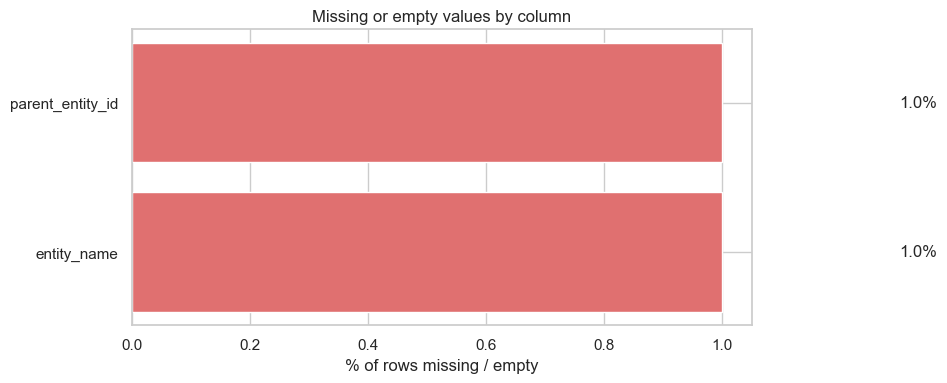

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
all_missing = (df.isnull().sum() + (df == '').sum())
all_missing_pct = (all_missing / len(df) * 100).sort_values(ascending=False)
all_missing_pct = all_missing_pct[all_missing_pct > 0]
bars = ax.barh(all_missing_pct.index, all_missing_pct.values, color='#e07070')
ax.set_xlabel('% of rows missing / empty')
ax.set_title('Missing or empty values by column')
for bar, val in zip(bars, all_missing_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.show()

## 3. Jurisdiction & entity type breakdown

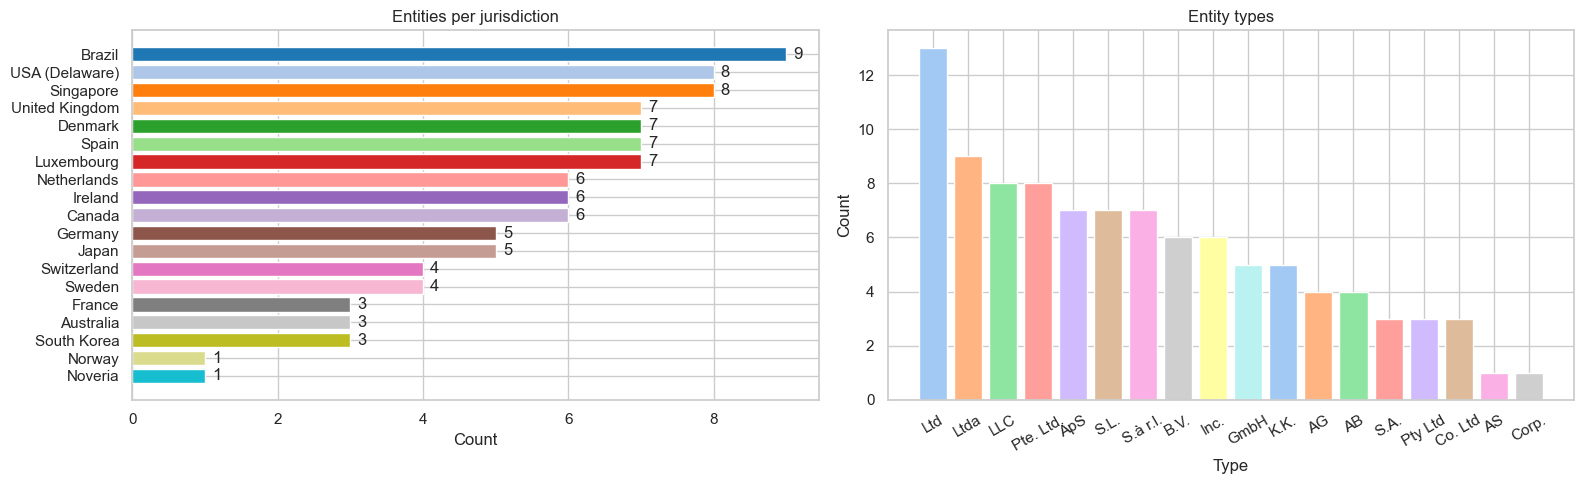

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Entities per jurisdiction
jur_counts = df['jurisdiction'].value_counts()
colors = sns.color_palette('tab20', len(jur_counts))
axes[0].barh(jur_counts.index[::-1], jur_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Entities per jurisdiction')
axes[0].set_xlabel('Count')
for i, (val, idx) in enumerate(zip(jur_counts.values[::-1], jur_counts.index[::-1])):
    axes[0].text(val + 0.1, i, str(val), va='center')

# Entity types
type_counts = df['entity_type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=sns.color_palette('pastel', len(type_counts)))
axes[1].set_title('Entity types')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Status distribution

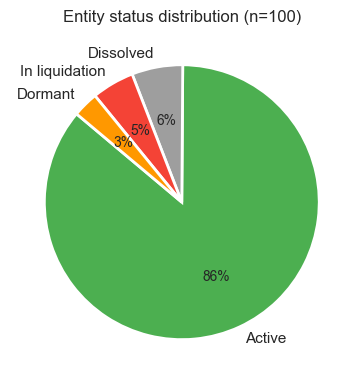

status
Active            86
Dissolved          6
In liquidation     5
Dormant            3


In [9]:
status_counts = df['status'].value_counts()
STATUS_COLORS = {
    'Active': '#4caf50',
    'Dormant': '#ff9800',
    'In liquidation': '#f44336',
    'Dissolved': '#9e9e9e',
}
colors = [STATUS_COLORS.get(s, '#90caf9') for s in status_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
wedges, texts, autotexts = ax.pie(
    status_counts.values, labels=status_counts.index,
    colors=colors, autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Entity status distribution (n=100)')
plt.tight_layout()
plt.show()

print(status_counts.to_string())

## 5. Asset class breakdown

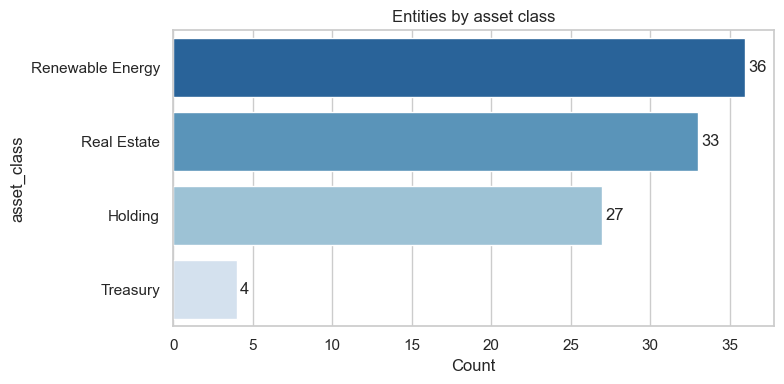

In [10]:
asset_counts = df['asset_class'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=asset_counts.values, y=asset_counts.index, ax=ax,
            palette='Blues_r', hue=asset_counts.index, legend=False)
ax.set_title('Entities by asset class')
ax.set_xlabel('Count')
for i, val in enumerate(asset_counts.values):
    ax.text(val + 0.2, i, str(val), va='center')
plt.tight_layout()
plt.show()

## 6. Annual filing status

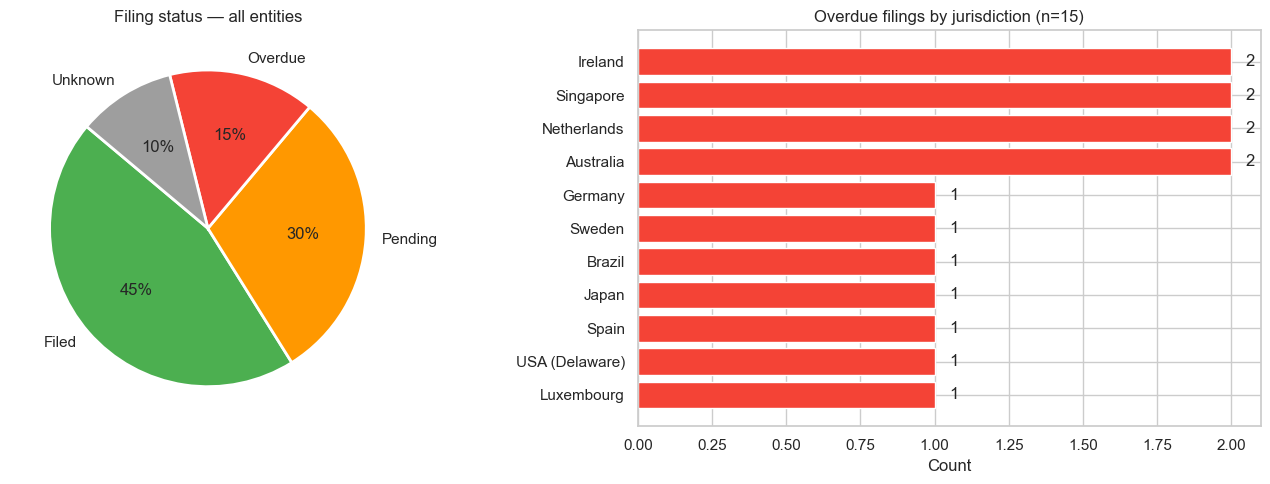

In [11]:
filing_counts = df['annual_filing_status'].value_counts()
FILING_COLORS = {
    'Filed': '#4caf50',
    'Pending': '#ff9800',
    'Overdue': '#f44336',
    'Unknown': '#9e9e9e',
}
colors = [FILING_COLORS.get(s, '#90caf9') for s in filing_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall pie
axes[0].pie(filing_counts.values, labels=filing_counts.index, colors=colors,
            autopct='%1.0f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Filing status — all entities')

# Overdue entities by jurisdiction
overdue = df[df['annual_filing_status'] == 'Overdue']
overdue_by_jur = overdue['jurisdiction'].value_counts()
axes[1].barh(overdue_by_jur.index[::-1], overdue_by_jur.values[::-1], color='#f44336')
axes[1].set_title(f'Overdue filings by jurisdiction (n={len(overdue)})')
axes[1].set_xlabel('Count')
for i, val in enumerate(overdue_by_jur.values[::-1]):
    axes[1].text(val + 0.05, i, str(val), va='center')

plt.tight_layout()
plt.show()

In [12]:
# Table: all overdue entities
overdue_table = df[df['annual_filing_status'] == 'Overdue'][[
    'entity_id', 'entity_name', 'jurisdiction', 'annual_filing_due', 'status', 'asset_class'
]].sort_values('annual_filing_due')
display(overdue_table)

,entity_id,entity_name,jurisdiction,annual_filing_due,status,asset_class
36,FGI-037,FGI Yokohama Retail II K.K.,Japan,2025-12-29,Active,Real Estate
74,FGI-075,FGI Sydney Retail IV Pty Ltd,Australia,2025-12-30,Active,Real Estate
88,FGI-089,FGI Melbourne Residential V Pty Ltd,Australia,2026-01-14,Active,Holding
92,FGI-093,FGI Esch-sur-Alzette Office II S.à r.l.,Luxembourg,2026-01-15,Active,Real Estate
43,FGI-044,FGI Northern Solar Holdings Pte. Ltd.,Singapore,2026-01-17,Active,Renewable Energy
54,FGI-055,FGI Valencia Retail VIII S.L.,Spain,2026-01-28,Active,Holding
10,FGI-011,FGI Malmö Residential IV AB,Sweden,2026-02-07,Active,Real Estate
79,FGI-080,FGI Utrecht Office VII B.V.,Netherlands,2026-03-21,Active,Holding
3,FGI-004,FGI Dublin Mixed-Use III Ltd,Ireland,2026-03-22,Active,Real Estate
61,FGI-062,FGI Atlas Hydro Holdings B.V.,Netherlands,2026-03-25,Active,Renewable Energy


## 7. Board mandate expiry — urgency heatmap

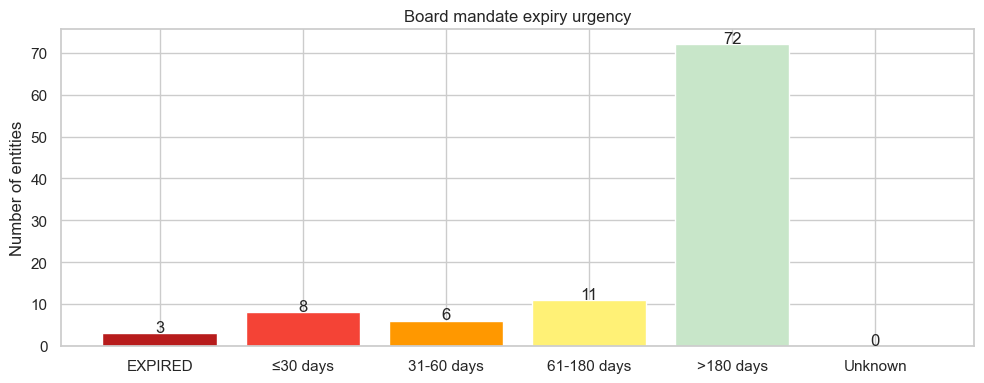


Entities with mandate expiring within 60 days or already expired:


,entity_id,entity_name,jurisdiction,board_mandate_expiry,days_to_mandate_expiry,status
33,FGI-034,FGI Toronto Retail IV Inc.,Canada,2026-06-02,-8,In liquidation
1,FGI-002,FGI Europe Holdings B.V.,Netherlands,2026-06-03,-7,Active
66,FGI-067,FGI Atlas Grid Holdings Pte. Ltd.,Singapore,2026-06-04,-6,Active
36,FGI-037,FGI Yokohama Retail II K.K.,Japan,2026-06-13,3,Active
4,FGI-005,FGI Fjord Solar Holdings B.V.,Netherlands,2026-06-19,9,Active
17,FGI-018,FGI Copenhagen Hotel V ApS,Denmark,2026-06-23,13,Dormant
77,FGI-078,FGI Aurora Wind Holdings Inc.,Canada,2026-06-27,17,Active
48,FGI-049,FGI Leeds Retail V Ltd,United Kingdom,2026-06-28,18,Dormant
12,FGI-013,FGI Copenhagen Residential VIII ApS,Denmark,2026-07-01,21,Active
70,FGI-071,FGI Malmö Mixed-Use V AB,Sweden,2026-07-03,23,Dissolved


In [13]:
df['board_mandate_expiry_dt'] = pd.to_datetime(df['board_mandate_expiry'], errors='coerce')
df['days_to_mandate_expiry'] = (df['board_mandate_expiry_dt'].dt.date.apply(
    lambda x: (x - TODAY).days if pd.notna(x) else None
))

def mandate_urgency(days):
    if days is None: return 'Unknown'
    if days < 0: return 'EXPIRED'
    if days <= 30: return '≤30 days'
    if days <= 60: return '31-60 days'
    if days <= 180: return '61-180 days'
    return '>180 days'

df['mandate_urgency'] = df['days_to_mandate_expiry'].apply(mandate_urgency)

urgency_order = ['EXPIRED', '≤30 days', '31-60 days', '61-180 days', '>180 days', 'Unknown']
urgency_colors = ['#b71c1c', '#f44336', '#ff9800', '#fff176', '#c8e6c9', '#e0e0e0']
urgency_counts = df['mandate_urgency'].value_counts().reindex(urgency_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(urgency_counts.index, urgency_counts.values, color=urgency_colors)
ax.set_title('Board mandate expiry urgency')
ax.set_ylabel('Number of entities')
for bar, val in zip(bars, urgency_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center')
plt.tight_layout()
plt.show()

print('\nEntities with mandate expiring within 60 days or already expired:')
urgent = df[df['days_to_mandate_expiry'].notna() & (df['days_to_mandate_expiry'] <= 60)][[
    'entity_id', 'entity_name', 'jurisdiction', 'board_mandate_expiry', 'days_to_mandate_expiry', 'status'
]].sort_values('days_to_mandate_expiry')
display(urgent)

## 8. Ownership structure — depth and anomalies

In [14]:
# Build parent map and detect issues
entity_ids = set(df['entity_id'])
parent_map = dict(zip(df['entity_id'], df['parent_entity_id']))

issues = []

# Orphan parents (parent_entity_id points to non-existent entity)
for eid, pid in parent_map.items():
    if pd.notna(pid) and pid not in entity_ids:
        issues.append({'entity_id': eid, 'issue': f'Parent {pid} not in register', 'severity': 'CRITICAL'})

# Circular ownership
def has_cycle(start, parent_map, entity_ids, max_depth=20):
    visited = set()
    current = start
    for _ in range(max_depth):
        if current in visited:
            return True
        visited.add(current)
        current = parent_map.get(current)
        if current is None or pd.isna(current) or current not in entity_ids:
            return False
    return True

for eid in entity_ids:
    if has_cycle(eid, parent_map, entity_ids):
        issues.append({'entity_id': eid, 'issue': 'Circular ownership detected', 'severity': 'CRITICAL'})

issues_df = pd.DataFrame(issues).drop_duplicates()
print(f'Structural ownership issues: {len(issues_df)}')
display(issues_df)

Structural ownership issues: 3


,entity_id,issue,severity
0,FGI-050,Parent FGI-099X not in register,CRITICAL
1,FGI-019,Circular ownership detected,CRITICAL
2,FGI-012,Circular ownership detected,CRITICAL


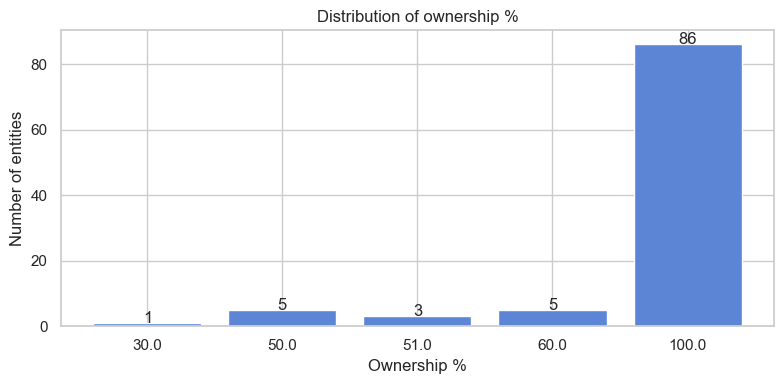


Joint ventures / minority holdings (14 entities):


,entity_id,entity_name,jurisdiction,ownership_pct,status
3,FGI-004,FGI Dublin Mixed-Use III Ltd,Ireland,60.0,Active
8,FGI-009,FGI Frankfurt Logistics VIII GmbH,Germany,50.0,Active
9,FGI-010,FGI Solar Grid Holdings ApS,Denmark,60.0,Active
10,FGI-011,FGI Malmö Residential IV AB,Sweden,51.0,Active
11,FGI-012,FGI Frankfurt Logistics IV GmbH,Germany,30.0,Active
23,FGI-024,FGI Copenhagen Retail VII ApS,Denmark,60.0,Active
48,FGI-049,FGI Leeds Retail V Ltd,United Kingdom,51.0,Dormant
53,FGI-054,FGI Dublin Residential III Ltd,Ireland,50.0,Active
61,FGI-062,FGI Atlas Hydro Holdings B.V.,Netherlands,50.0,Active
70,FGI-071,FGI Malmö Mixed-Use V AB,Sweden,60.0,Dissolved


In [15]:
# Ownership percentage distribution
fig, ax = plt.subplots(figsize=(8, 4))
ownership_counts = df['ownership_pct'].value_counts().sort_index()
ax.bar(ownership_counts.index.astype(str), ownership_counts.values, color='#5c85d6')
ax.set_title('Distribution of ownership %')
ax.set_xlabel('Ownership %')
ax.set_ylabel('Number of entities')
for i, (val, idx) in enumerate(zip(ownership_counts.values, ownership_counts.index)):
    ax.text(i, val + 0.1, str(val), ha='center')
plt.tight_layout()
plt.show()

# JV entities (non-100% ownership)
jv = df[df['ownership_pct'] < 100][['entity_id','entity_name','jurisdiction','ownership_pct','status']]
print(f'\nJoint ventures / minority holdings ({len(jv)} entities):')
display(jv)

## 9. Data quality issues — full scan

In [16]:
dq_issues = []

# Missing entity name
for _, row in df.iterrows():
    if pd.isna(row['entity_name']) or str(row['entity_name']).strip() == '':
        dq_issues.append({'entity_id': row['entity_id'], 'issue': 'Missing entity name', 'severity': 'HIGH'})

# Duplicate entity names
name_counts = df['entity_name'].value_counts()
dup_names = name_counts[name_counts > 1].index
for name in dup_names:
    ids = df[df['entity_name'] == name]['entity_id'].tolist()
    dq_issues.append({'entity_id': ', '.join(ids), 'issue': f'Duplicate entity name: "{name}"', 'severity': 'HIGH'})

# Future incorporation date
df['incorporation_date_dt'] = pd.to_datetime(df['incorporation_date'], errors='coerce')
future_inc = df[df['incorporation_date_dt'].dt.date > TODAY]
for _, row in future_inc.iterrows():
    dq_issues.append({'entity_id': row['entity_id'], 'issue': f'Incorporation date in the future: {row["incorporation_date"]}', 'severity': 'HIGH'})

# Suspicious jurisdiction
KNOWN_JURISDICTIONS = [
    'Norway','Netherlands','United Kingdom','Ireland','Switzerland','Germany',
    'Denmark','Sweden','Spain','France','Luxembourg','USA (Delaware)','Canada',
    'Brazil','Singapore','Japan','South Korea','Australia'
]
for _, row in df.iterrows():
    if row['jurisdiction'] not in KNOWN_JURISDICTIONS:
        dq_issues.append({'entity_id': row['entity_id'], 'issue': f'Unknown/suspicious jurisdiction: "{row["jurisdiction"]}"', 'severity': 'CRITICAL'})

# Dissolved entities with active board / as parent
dissolved = df[df['status'].isin(['Dissolved'])]
dissolved_ids = set(dissolved['entity_id'])
for _, row in dissolved.iterrows():
    if pd.notna(row.get('board_members')) and str(row['board_members']).strip():
        # Check if any entity has this as parent
        children = df[df['parent_entity_id'] == row['entity_id']]
        if len(children) > 0:
            dq_issues.append({'entity_id': row['entity_id'], 'issue': f'Dissolved entity is parent of {len(children)} active entity(ies)', 'severity': 'CRITICAL'})

# Ownership % anomalies
for _, row in df.iterrows():
    if pd.notna(row['ownership_pct']) and (row['ownership_pct'] > 100 or row['ownership_pct'] <= 0):
        dq_issues.append({'entity_id': row['entity_id'], 'issue': f'Invalid ownership %: {row["ownership_pct"]}', 'severity': 'CRITICAL'})

dq_df = pd.DataFrame(dq_issues)
print(f'Total data quality issues found: {len(dq_df)}')
display(dq_df.sort_values('severity'))

Total data quality issues found: 4


,entity_id,issue,severity
3,FGI-033,"Unknown/suspicious jurisdiction: ""Noveria""",CRITICAL
0,FGI-052,Missing entity name,HIGH
1,"FGI-014, FGI-015","Duplicate entity name: ""FGI Madrid Retail II S...",HIGH
2,FGI-041,Incorporation date in the future: 2027-03-15,HIGH


## 10. Board updates — messy JSON

In [17]:
with open('data/board_updates.json') as f:
    updates_raw = json.load(f)

updates = pd.DataFrame(updates_raw)
print(f'Board updates: {len(updates)} entries')
print(f'Columns: {list(updates.columns)}')
display(updates.head(5))

Board updates: 30 entries
Columns: ['date', 'entity_name', 'change_type', 'details', 'source']


,date,entity_name,change_type,details,source
0,15 May 2026,FGI- Copenhagen Retail VII ApS,Board member resignation,Jeffrey Chavez resigned effective 05/29/2026. ...,Email from Van der Berg CS
1,2026-05-31,FGI Singapore Residential VIII Pte.,Board member appointment,Timothy Duncan appointed as director effective...,Email from Lux Corporate Management
2,05/25/2026,FGI Fjord Wind Holdings,Address change,Registered office changed to a new address eff...,Scanned letter
3,05/20/2026,FGI Copenhagen Residential VIII,Board member resignation,Anthony Rodriguez resigned effective 06/03/202...,Phone note (transcribed)
4,2026-04-30,FGI Copenhagen Hotel II ApS,Board member appointment,Stephanie Ross appointed as director effective...,Email from Van der Berg CS


Date formats present in board_updates:
<StringArray>
['15 May 2026',  '2026-05-31',  '05/25/2026',  '05/20/2026',  '2026-04-30',
 '11 May 2026',  '2026-05-25',  '04/30/2026',  '2026-05-29',  '2026-05-28',
 '05 May 2026',  '06/01/2026',  '2026-05-17',  '2026-05-18', '12 May 2026',
  '2026-05-12', '28 Apr 2026',  '05/02/2026', '23 May 2026', '27 Apr 2026',
 '25 Apr 2026',  '2026-05-10', '17 May 2026',  '2026-05-15',  '05/07/2026',
  '05/05/2026',  '2026-05-27', '27 May 2026']
Length: 28, dtype: str


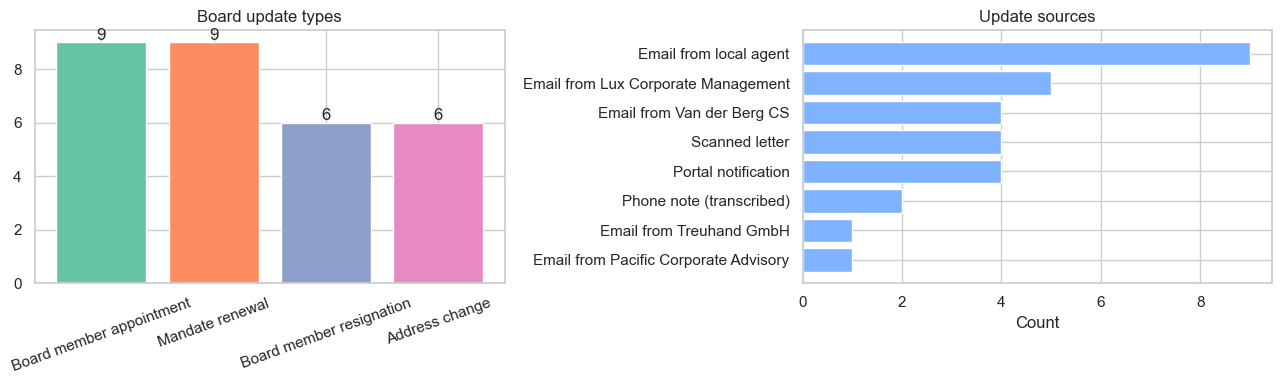

In [18]:
# Date format chaos
print('Date formats present in board_updates:')
print(updates['date'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Change type breakdown
ct_counts = updates['change_type'].value_counts()
axes[0].bar(ct_counts.index, ct_counts.values, color=sns.color_palette('Set2', len(ct_counts)))
axes[0].set_title('Board update types')
axes[0].tick_params(axis='x', rotation=20)
for i, val in enumerate(ct_counts.values):
    axes[0].text(i, val + 0.1, str(val), ha='center')

# Source breakdown
src_counts = updates['source'].value_counts()
axes[1].barh(src_counts.index[::-1], src_counts.values[::-1], color='#80b3ff')
axes[1].set_title('Update sources')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [19]:
# Match board updates to the register
register_names = set(df['entity_name'].dropna().str.strip())

def fuzzy_match(update_name, register_names):
    """Simple substring match — good enough for exploration."""
    name = update_name.strip().lstrip('- ').rstrip('.')
    for rn in register_names:
        if name in rn or rn in name:
            return rn
    # Try partial: first 20 chars
    for rn in register_names:
        if name[:20].strip() in rn:
            return rn
    return None

updates['matched_to'] = updates['entity_name'].apply(lambda n: fuzzy_match(n, register_names))
unmatched = updates[updates['matched_to'].isna()]

print(f'Matched: {updates["matched_to"].notna().sum()} / {len(updates)}')
print(f'\nUNMATCHED updates (ghost entities or name mismatch):')
display(unmatched[['date','entity_name','change_type','details','source']])

Matched: 21 / 30

UNMATCHED updates (ghost entities or name mismatch):


,date,entity_name,change_type,details,source
0,15 May 2026,FGI- Copenhagen Retail VII ApS,Board member resignation,Jeffrey Chavez resigned effective 05/29/2026. ...,Email from Van der Berg CS
6,2026-05-25,FGI SÃ£o Paulo Hotel VIII,Mandate renewal,Board mandate renewed for a further term; next...,Email from Lux Corporate Management
7,04/30/2026,FGI- Treasury & Financing S.Ã r.l.,Mandate renewal,Board mandate renewed for a further term; next...,Email from Van der Berg CS
21,2026-05-10,FGI- London Office II Ltd,Address change,Registered office changed to a new address eff...,Scanned letter
24,05/07/2026,FGI Helsinki Office I Oy,Mandate renewal,Notification received; entity not found in cur...,Email from local agent
25,05/05/2026,FGI Cape Town Solar (Pty) Ltd,Board member resignation,Notification received; entity not found in cur...,Email from local agent
26,2026-05-27,Northwind Capital Partners LLP,Address change,Notification received; entity not found in cur...,Email from local agent
27,2026-05-12,FGI Madrid Logistics (co-owned),Address change,Co-ownership note: FGI-010 is recorded as 60% ...,Email from Lux Corporate Management
29,27 May 2026,FGI Singapore Solar III,Mandate renewal,Open compliance items remain despite dissoluti...,Email from Pacific Corporate Advisory


## 11. External letters — ghost entities

In [20]:
# Entities mentioned in letters but not in the CSV
letter_entities = [
    # Luxembourg letter
    {'source': 'luxembourg_mandate_warning.pdf', 'entity': 'FGI Treasury & Financing S.à r.l.',
     'issue': 'Board members in letter (M. Fjellström, A. Weber) differ from CSV; mandate expiry also conflicts (letter: 2026-06-19, CSV: 2028-01-10)'},
    {'source': 'luxembourg_mandate_warning.pdf', 'entity': 'FGI Luxembourg Financng I S.à r.l.',
     'issue': 'Entity NOT in subsidiary register'},
    {'source': 'luxembourg_mandate_warning.pdf', 'entity': 'FGI Aurora Storage Holdings S.à r.l.',
     'issue': 'Entity NOT in subsidiary register'},
    # Singapore letter
    {'source': 'singapore_compliance_update.pdf', 'entity': 'FGI Singapore Solar III',
     'issue': 'Entity NOT in register; agent reports open compliance items on a supposedly dissolved entity'},
    # Netherlands letter
    {'source': 'netherlands_filing_reminder.pdf', 'entity': 'FGI Amsterdam Office II B.V.',
     'issue': 'Entity NOT in register; filing overdue since 2026-02-10'},
    {'source': 'netherlands_filing_reminder.pdf', 'entity': 'FGI Rotterdam Logistics I B.V.',
     'issue': 'Entity NOT in register; filing overdue since 2026-03-01'},
]
letter_df = pd.DataFrame(letter_entities)
display(letter_df)

,source,entity,issue
0,luxembourg_mandate_warning.pdf,FGI Treasury & Financing S.à r.l.,"Board members in letter (M. Fjellström, A. Web..."
1,luxembourg_mandate_warning.pdf,FGI Luxembourg Financng I S.à r.l.,Entity NOT in subsidiary register
2,luxembourg_mandate_warning.pdf,FGI Aurora Storage Holdings S.à r.l.,Entity NOT in subsidiary register
3,singapore_compliance_update.pdf,FGI Singapore Solar III,Entity NOT in register; agent reports open com...
4,netherlands_filing_reminder.pdf,FGI Amsterdam Office II B.V.,Entity NOT in register; filing overdue since 2...
5,netherlands_filing_reminder.pdf,FGI Rotterdam Logistics I B.V.,Entity NOT in register; filing overdue since 2...


## 12. Risk summary — everything in one place

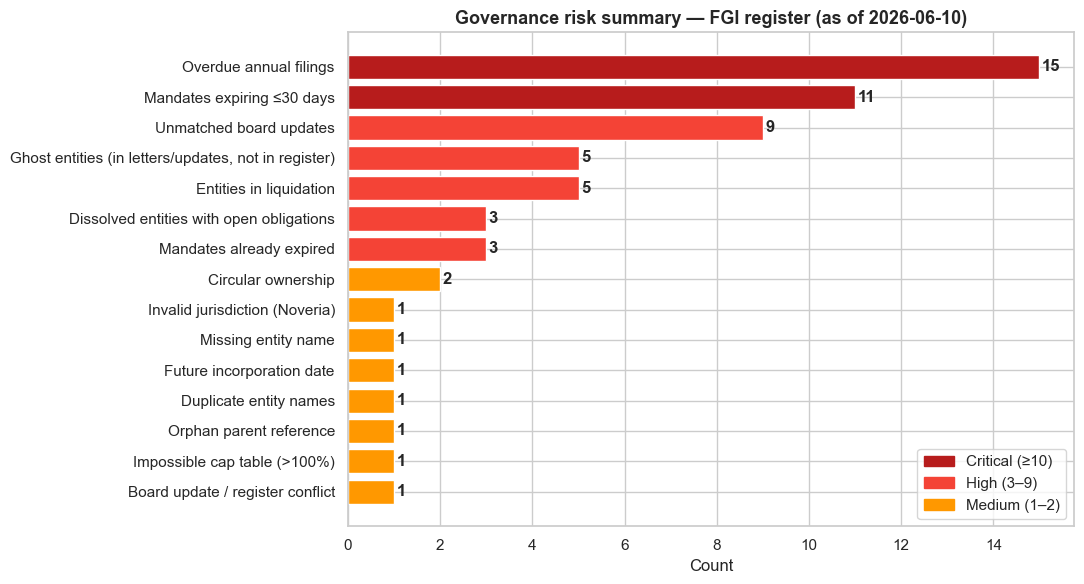

In [21]:
risk_summary = {
    'Overdue annual filings': len(df[df['annual_filing_status'] == 'Overdue']),
    'Mandates expiring ≤30 days': len(df[df['days_to_mandate_expiry'] <= 30]),
    'Mandates already expired': len(df[df['days_to_mandate_expiry'] < 0]),
    'Dissolved entities with open obligations': 3,  # FGI-003, FGI-020, + Singapore Solar III
    'Entities in liquidation': len(df[df['status'] == 'In liquidation']),
    'Ghost entities (in letters/updates, not in register)': 5,
    'Circular ownership': 2,  # FGI-012 / FGI-019
    'Invalid jurisdiction (Noveria)': 1,
    'Future incorporation date': len(future_inc),
    'Missing entity name': len(df[(df['entity_name'].isna()) | (df['entity_name'] == '')]),
    'Duplicate entity names': len(dup_names),
    'Orphan parent reference': len([i for i in issues_df['issue'] if 'Parent' in str(i) and 'not in register' in str(i)]),
    'Impossible cap table (>100%)': 1,  # FGI-010 per board updates
    'Board update / register conflict': 1,  # Lux Treasury mandate date
    'Unmatched board updates': len(unmatched),
}

risk_df = pd.Series(risk_summary).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
RISK_COLORS = [
    '#b71c1c' if v >= 10 else
    '#f44336' if v >= 3 else
    '#ff9800' if v >= 1 else
    '#e0e0e0'
    for v in risk_df.values
]
bars = ax.barh(risk_df.index[::-1], risk_df.values[::-1], color=RISK_COLORS[::-1])
ax.set_title('Governance risk summary — FGI register (as of 2026-06-10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(bars, risk_df.values[::-1]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

patches = [
    mpatches.Patch(color='#b71c1c', label='Critical (≥10)'),
    mpatches.Patch(color='#f44336', label='High (3–9)'),
    mpatches.Patch(color='#ff9800', label='Medium (1–2)'),
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

## 13. Board member load — who sits on the most boards?

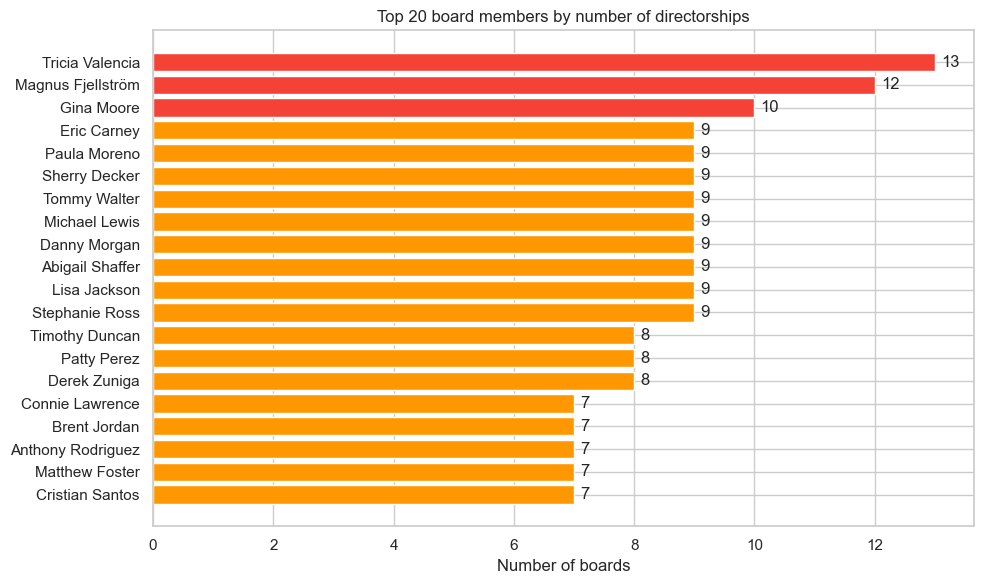


Total unique board members: 61
Total board seats: 356
Avg seats per person: 5.8


In [22]:
from collections import Counter

all_members = []
for _, row in df.iterrows():
    if pd.notna(row['board_members']):
        members = [m.strip() for m in str(row['board_members']).split(',')]
        all_members.extend(members)

member_counts = Counter(all_members)
top_members = pd.Series(member_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#f44336' if v >= 10 else '#ff9800' if v >= 7 else '#5c85d6' for v in top_members.values]
ax.barh(top_members.index[::-1], top_members.values[::-1], color=colors[::-1])
ax.set_title('Top 20 board members by number of directorships')
ax.set_xlabel('Number of boards')
for i, val in enumerate(top_members.values[::-1]):
    ax.text(val + 0.1, i, str(val), va='center')
plt.tight_layout()
plt.show()

print(f'\nTotal unique board members: {len(member_counts)}')
print(f'Total board seats: {sum(member_counts.values())}')
print(f'Avg seats per person: {sum(member_counts.values())/len(member_counts):.1f}')

## 14. Incorporation timeline

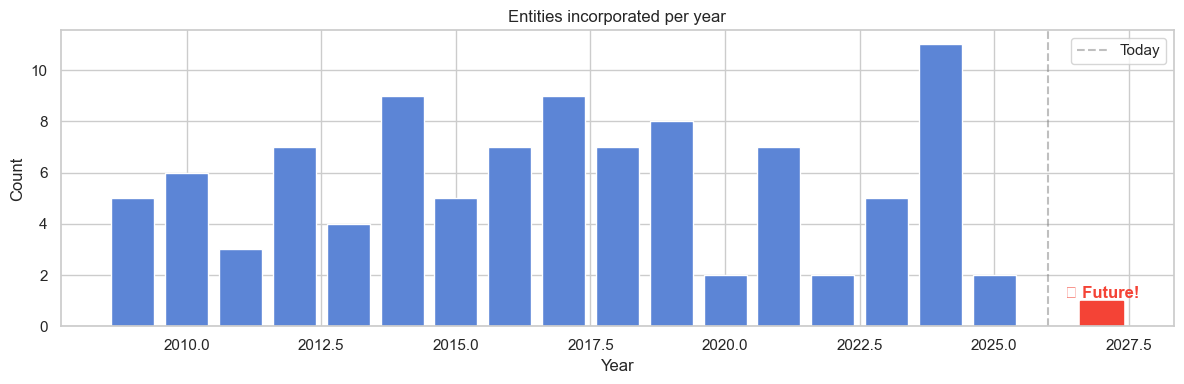

In [23]:
df['inc_year'] = df['incorporation_date_dt'].dt.year
inc_by_year = df.groupby('inc_year').size()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(inc_by_year.index.astype(int), inc_by_year.values, color='#5c85d6', edgecolor='white')
# Flag the future one
for bar, year in zip(bars, inc_by_year.index):
    if year > 2026:
        bar.set_color('#f44336')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                '⚠ Future!', ha='center', color='#f44336', fontweight='bold')
ax.set_title('Entities incorporated per year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.axvline(2026, color='gray', linestyle='--', alpha=0.5, label='Today')
ax.legend()
plt.tight_layout()
plt.show()

## Summary of key findings for the app build

| Category | Finding |
|---|---|
| **Overdue filings** | 14 entities in the CSV + 2 more in the Netherlands letter |
| **Mandate urgency** | 2 mandates already expired; several expiring within 30 days |
| **Circular ownership** | FGI-012 ↔ FGI-019 form a loop — impossible ownership chain |
| **Fictional jurisdiction** | FGI-033 registered in "Noveria" (Mass Effect) |
| **Future incorporation** | FGI-041 incorporated 2027-03-15 — hasn't happened yet |
| **Orphan parent** | FGI-050 references parent FGI-099X which doesn't exist |
| **Duplicate names** | FGI-014 and FGI-015 share the same entity name |
| **Missing name** | FGI-052 has no entity name |
| **Cap table error** | Board update notes FGI-010 at 60%+55% = 115% ownership |
| **Ghost entities** | 5 entities appear in letters/updates but not in the register |
| **Letter vs. CSV conflict** | Luxembourg letter gives different board members + mandate date for FGI Treasury & Financing |
| **Dissolved with open items** | FGI-003 is dissolved but is a parent; Singapore Solar III dissolved with open compliance |
| **Board member concentration** | Magnus Fjellström sits on ~13 boards |
